# Verstappen's telemetry- Miami 2024

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("verstappen_telemetry_miami_2024.csv")

print(df)

       Unnamed: 0                     Date    RPM  Speed  nGear  Throttle  \
0               0  2024-05-05 20:03:23.810  10082      0      1        15   
1               1  2024-05-05 20:03:24.170  10221      0      1        15   
2               2  2024-05-05 20:03:24.530   7981     10      1        15   
3               3  2024-05-05 20:03:24.810   6021     16      1        16   
4               4  2024-05-05 20:03:25.169   4264     30      1        27   
...           ...                      ...    ...    ...    ...       ...   
20650       20650  2024-05-05 21:34:20.627  10907    271      7       100   
20651       20651  2024-05-05 21:34:20.947  11011    278      7       100   
20652       20652  2024-05-05 21:34:21.187  11122    279      7        52   
20653       20653  2024-05-05 21:34:21.387  10714    275      7         0   
20654       20654  2024-05-05 21:34:21.547  10742    270      7         0   

       Brake  DRS Source                    Time             SessionTime  


In [3]:
df['SessionTime'] = pd.to_timedelta(df['SessionTime']).dt.total_seconds()

print(df.head())
print(df.tail())

   Unnamed: 0                     Date    RPM  Speed  nGear  Throttle  Brake  \
0           0  2024-05-05 20:03:23.810  10082      0      1        15   True   
1           1  2024-05-05 20:03:24.170  10221      0      1        15   True   
2           2  2024-05-05 20:03:24.530   7981     10      1        15  False   
3           3  2024-05-05 20:03:24.810   6021     16      1        16  False   
4           4  2024-05-05 20:03:25.169   4264     30      1        27  False   

   DRS Source                    Time  SessionTime  
0    1    car  0 days 00:00:00.014000     3343.042  
1    1    car  0 days 00:00:00.374000     3343.402  
2    1    car  0 days 00:00:00.734000     3343.762  
3    1    car  0 days 00:00:01.014000     3344.042  
4    1    car  0 days 00:00:01.373000     3344.401  
       Unnamed: 0                     Date    RPM  Speed  nGear  Throttle  \
20650       20650  2024-05-05 21:34:20.627  10907    271      7       100   
20651       20651  2024-05-05 21:34:20.947  110

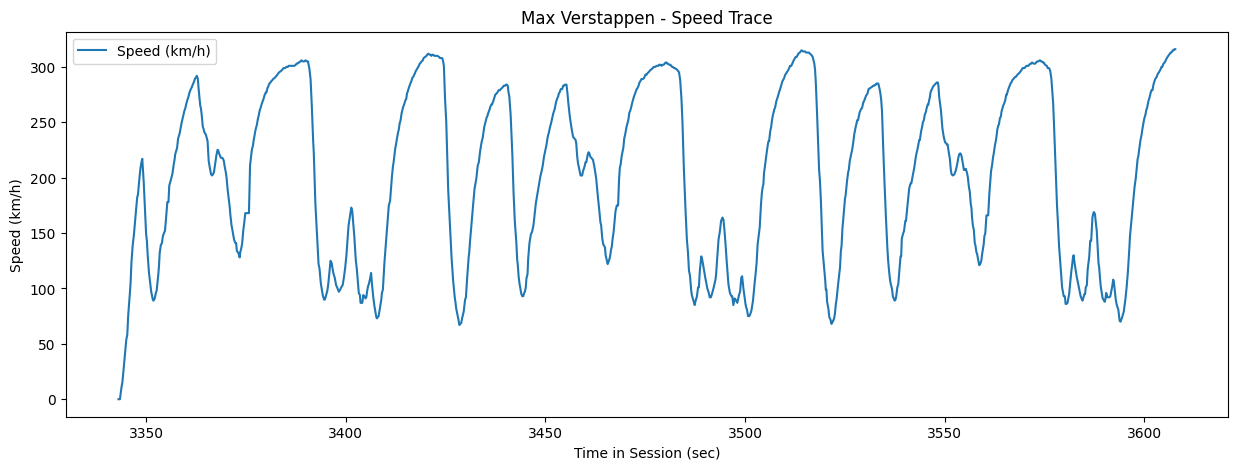

In [14]:
fig1 = plt.figure(figsize=(15, 5))

plt.plot(df['SessionTime'][:1000], df['Speed'][:1000], label='Speed (km/h)')

plt.title("Max Verstappen - Speed Trace")
plt.xlabel("Time in Session (sec)")
plt.ylabel("Speed (km/h)")
plt.legend()

plt.show()
plt.close(fig1)

In [5]:
top_speed = df['Speed'].max()
print(f"Max Speed: {top_speed} km/h")

Max Speed: 322 km/h


In [6]:
top_speed_data = df[df['Speed'] == top_speed]
print(top_speed_data[['SessionTime', 'Speed', 'nGear', 'RPM', 'DRS']])

       SessionTime  Speed  nGear    RPM  DRS
12639     6681.332    322      8  11351    0
12640     6681.812    322      8  11275    0
12994     6773.172    322      8  11386    0
14371     7138.654    322      8  11403    0
14714     7230.495    322      8  11345    0
14715     7230.815    322      8  11424    0
14716     7231.055    322      8  11279    0
15752     7504.895    322      8  11493    0
16083     7596.735    322      8  11265    0
18168     8145.618    322      8  11454    0


Data queries reveal Verstappen hit a peak velocity of 322 km/h at multiple points during the race. However, cross-referencing this with the DRS telemetry shows a value of 0 (closed) during every top-speed event.

Because the Drag Reduction System (DRS) provides a massive top-speed advantage, hitting V-max without it strongly indicates he was running in "clean air" (leading the pack with no cars within a 1-second gap to trigger DRS).

This highlights the aerodynamic efficiency and the advantage on the straights offered by the Red Bull car’s configuration for the Miami race, which allows it to reach top speed using engine power alone, without the need for slipstreaming.

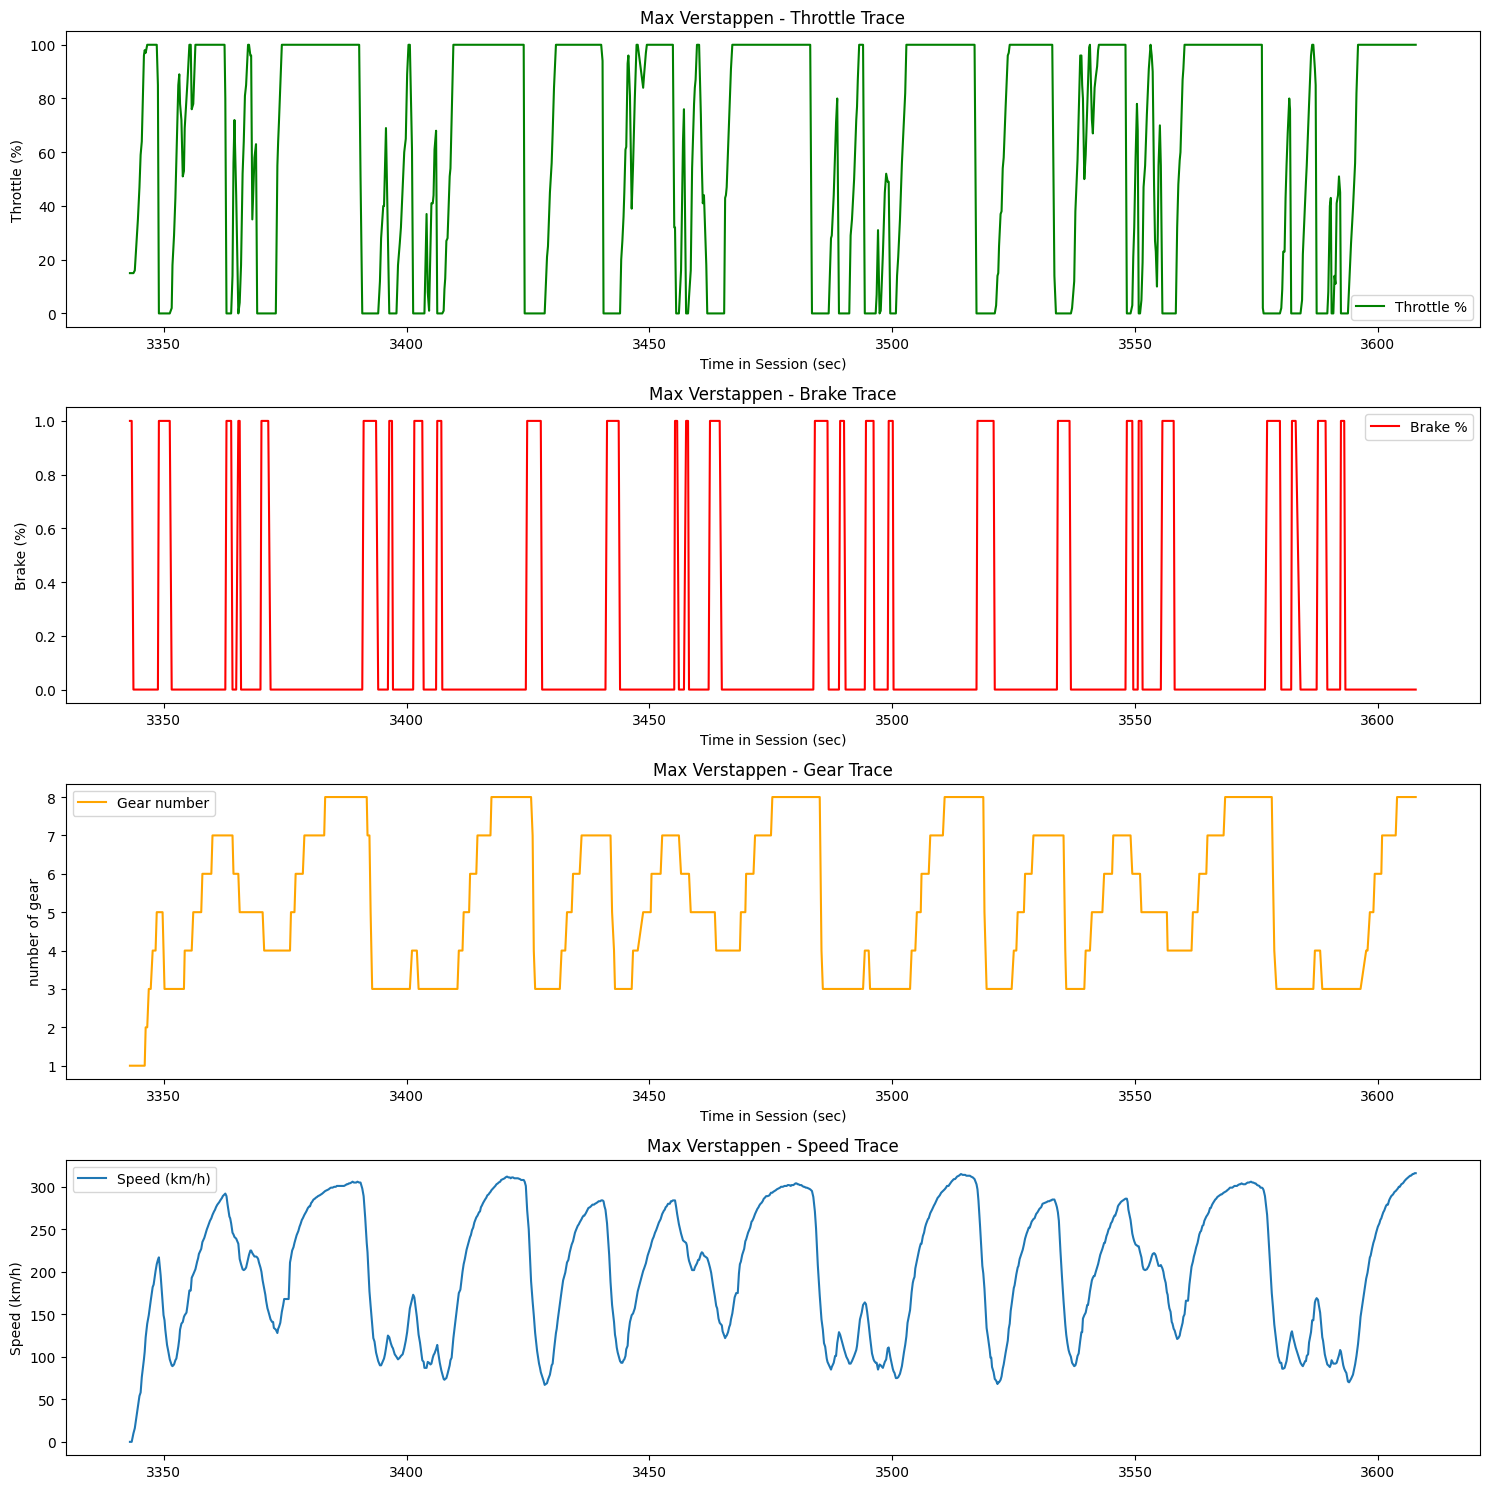

In [19]:
fig2 = plt.figure(figsize=(15, 15))

# brake trace
plt.subplot(4, 1, 1)
plt.plot(df['SessionTime'][:1000], df['Throttle'][:1000], color='green', label='Throttle %')

plt.title("Max Verstappen - Throttle Trace")
plt.xlabel("Time in Session (sec)")
plt.ylabel("Throttle (%)")
plt.legend()

#brake trace
plt.subplot(4, 1, 2)
plt.plot(df['SessionTime'][:1000], df['Brake'][:1000], color='red', label='Brake %')

plt.title("Max Verstappen - Brake Trace")
plt.xlabel("Time in Session (sec)")
plt.ylabel("Brake (%)")
plt.legend()

# gear trace
plt.subplot(4, 1, 3)
plt.plot(df['SessionTime'][:1000], df['nGear'][:1000], color='orange', label='Gear number')

plt.title("Max Verstappen - Gear Trace")
plt.xlabel("Time in Session (sec)")
plt.ylabel("number of gear")
plt.legend()

# speed trace
plt.subplot(4, 1, 4) 
plt.plot(df['SessionTime'][:1000], df['Speed'][:1000], label='Speed (km/h)')
plt.title("Max Verstappen - Speed Trace")
plt.ylabel("Speed (km/h)")
plt.legend()

plt.tight_layout()
plt.show()

- When the throttle and brake graphs are overlaid, it is clear that there is no overlap between them, and the intervals between the signals are practically zero. Verstappen is not ‘coasting’. Within milliseconds, he goes from full throttle to full braking. This aggressive and decisive action minimises time lost in transition zones and demonstrates excellent control over the car.
- During heavy deceleration, the Gear trace shows a perfect, rapid "staircase" downshift. He isn't just relying on the physical brakes; he is flawlessly using the engine's resistance to slow the car down, which prevents tire lockups and keeps the car perfectly balanced on corner entry.
- In the slowest sections of the track (where the speed curve shows sharp drops), the throttle position curve rises and falls sharply. As F1 cars are not equipped with automatic traction control, this data proves that Max has a ‘perfect feel’ for the accelerator pedal, allowing him to balance on the edge of grip without causing the rear tyres to slip.

### Calculating lap times
Because the raw F1 telemetry dataset does not contain explicit "Lap Number" markers, I engineered a custom Threshold-with-Cooldown algorithm to isolate individual laps and calculate their exact durations.
1. **The Trigger Condition**
The Miami International Autodrome's start/finish line is located at the end of the longest straightaway. The algorithm scans the telemetry line-by-line looking for a peak speed of >= 315 km/h to serve as the "tripwire" indicating the start of a new lap.

1. **The Cooldown Lockout**
An F1 car takes several seconds to decelerate from 315 km/h for Turn 1. Without a lockout, a naive algorithm would trigger multiple "laps" in a single second on the same straightaway. To prevent this false-positive data noise, I implemented a 75-second cooldown timer. Because an average race pace lap in Miami is roughly 90–93 seconds, this 75-second window is perfectly sized. It ignores all deceleration noise and only begins looking for the next 315 km/h peak right as Verstappen returns to the main straight for the following lap.

In [21]:
lap_start_times = []
cooldown_until = 0

for curr_time, curr_speed in zip(df['SessionTime'], df['Speed']):
    if curr_speed >= 315 and curr_time > cooldown_until:
        lap_start_times.append(curr_time)
        cooldown_until = curr_time + 75 # we cooldown for 75 because the lap is about 90s long

In [22]:
print("Lap Start Times (in sec):")
for i, time in enumerate(lap_start_times):
    print(f"Lap {i+1} started at: {time:.3f}s")

Lap Start Times (in sec):
Lap 1 started at: 3514.162s
Lap 2 started at: 3607.162s
Lap 3 started at: 3701.002s
Lap 4 started at: 3794.123s
Lap 5 started at: 3886.843s
Lap 6 started at: 3979.283s
Lap 7 started at: 4072.083s
Lap 8 started at: 4165.364s
Lap 9 started at: 4258.724s
Lap 10 started at: 4352.364s
Lap 11 started at: 4445.604s
Lap 12 started at: 4538.605s
Lap 13 started at: 4631.726s
Lap 14 started at: 4724.406s
Lap 15 started at: 4816.966s
Lap 16 started at: 4909.646s
Lap 17 started at: 5002.647s
Lap 18 started at: 5095.647s
Lap 19 started at: 5187.967s
Lap 20 started at: 5281.087s
Lap 21 started at: 5373.807s
Lap 22 started at: 5480.848s
Lap 23 started at: 5592.609s
Lap 24 started at: 5685.049s
Lap 25 started at: 5777.089s
Lap 26 started at: 5869.370s
Lap 27 started at: 5961.850s
Lap 28 started at: 6557.172s
Lap 29 started at: 6679.492s
Lap 30 started at: 6771.373s
Lap 31 started at: 6863.093s
Lap 32 started at: 6954.214s
Lap 33 started at: 7045.534s
Lap 34 started at: 7136.97

In [25]:
print("Lap Times")
for i in range(len(lap_start_times) - 1):
    lap_duration = lap_start_times[i+1] - lap_start_times[i]
    print(f"Lap {i+1} Time: {lap_duration:.3f} s")

Lap Times
Lap 1 Time: 93.000 s
Lap 2 Time: 93.840 s
Lap 3 Time: 93.121 s
Lap 4 Time: 92.720 s
Lap 5 Time: 92.440 s
Lap 6 Time: 92.800 s
Lap 7 Time: 93.281 s
Lap 8 Time: 93.360 s
Lap 9 Time: 93.640 s
Lap 10 Time: 93.240 s
Lap 11 Time: 93.001 s
Lap 12 Time: 93.121 s
Lap 13 Time: 92.680 s
Lap 14 Time: 92.560 s
Lap 15 Time: 92.680 s
Lap 16 Time: 93.001 s
Lap 17 Time: 93.000 s
Lap 18 Time: 92.320 s
Lap 19 Time: 93.120 s
Lap 20 Time: 92.720 s
Lap 21 Time: 107.041 s
Lap 22 Time: 111.761 s
Lap 23 Time: 92.440 s
Lap 24 Time: 92.040 s
Lap 25 Time: 92.281 s
Lap 26 Time: 92.480 s
Lap 27 Time: 595.322 s
Lap 28 Time: 122.320 s
Lap 29 Time: 91.881 s
Lap 30 Time: 91.720 s
Lap 31 Time: 91.121 s
Lap 32 Time: 91.320 s
Lap 33 Time: 91.439 s
Lap 34 Time: 91.401 s
Lap 35 Time: 91.800 s
Lap 36 Time: 91.161 s
Lap 37 Time: 91.320 s
Lap 38 Time: 91.801 s
Lap 39 Time: 91.040 s
Lap 40 Time: 91.880 s
Lap 41 Time: 91.521 s
Lap 42 Time: 91.600 s
Lap 43 Time: 91.401 s
Lap 44 Time: 91.359 s
Lap 45 Time: 91.280 s
Lap 4

In [26]:
table_data = []

for i in range(len(lap_start_times) - 1):
    lap_duration = lap_start_times[i+1] - lap_start_times[i]
    
    table_data.append({
        "Lap Number": int(i + 1),
        "Start Time (sec)": round(lap_start_times[i], 3),
        "Lap Time (sec)": round(lap_duration, 3)
    })

laps_df = pd.DataFrame(table_data)

laps_df

,Lap Number,Start Time (sec),Lap Time (sec)
0,1,3514.162,93.000
1,2,3607.162,93.840
2,3,3701.002,93.121
3,4,3794.123,92.720
4,5,3886.843,92.440
5,6,3979.283,92.800
6,7,4072.083,93.281
7,8,4165.364,93.360
8,9,4258.724,93.640
9,10,4352.364,93.240


The algorithm calculated Lap 27 at a massive 595.322 seconds. In reality, a single lap takes ~90 seconds. This anomaly occurred because our code was strictly looking for a top speed of 315 km/h to trigger a new lap. During the Safety Car period, Verstappen was forced to drive far below this speed limit for multiple laps. Consequently, the algorithm stayed "asleep" and grouped Laps 27, 28, 29, 30, 31, and 32 into one single, giant 10-minute block until the race restarted and he finally hit 315 km/h again.